<div style="text-align:center;">
    <img src="http://www.cs.wm.edu/~rml/images/wm_horizontal_single_line_full_color.png">
    <h1>CSCI 416-01/516-01 final exam</h1>
    <h1>Fall 2025</h1>
    <h1>Problem 0: Imbalanced learning</h1>
</div>

# Name: Aidan Basloe

# The task

This problem involves performing some experiments in dealing with imbalanced datasets and interpreting the results.

The instructions may be found [here](#What-you-are-to-do).

# Prologue

In [1]:
# We will use the imbalanced learning module.  See https://imbalanced-learn.org
%pip install imblearn
%pip install numpy==1.26.4 pandas seaborn matplotlib scikit-learn

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 12.9/12.9 MB 73.5 MB/s  0:00:00
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 8.9/8.9 MB 79.1 MB/s  0:00:00
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ------------------ --------------------- 19.1/41.3 MB 86.6 MB/s eta 0:00:01
   ------------------------------------- -- 38.3/41.3 MB 87.0 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 79.6 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- ---------------------------------- 1/7 [numpy]
   ----- -----

In [2]:
from collections import Counter
from math import sqrt

from imblearn.metrics import geometric_mean_score
from imblearn.pipeline import Pipeline  # Scikit-learn's Pipeline class doesn't play well with imblearn.
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import DetCurveDisplay, RocCurveDisplay

# Read the data

In [3]:
filename = 'oil-spill.csv'
df = pd.read_csv(filename, header=None)

## Look at the data

You should look at the text file <code>oil-spill.csv</code> to get a feel for the data.

For instance, column 0 looks bogus, like some manner of sequence indicator:

In [4]:
print(df.iloc[:20,0])

0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
9     10
10    11
11     1
12     2
13     3
14     4
15     5
16     6
17     7
18     8
19     9
Name: 0, dtype: int64


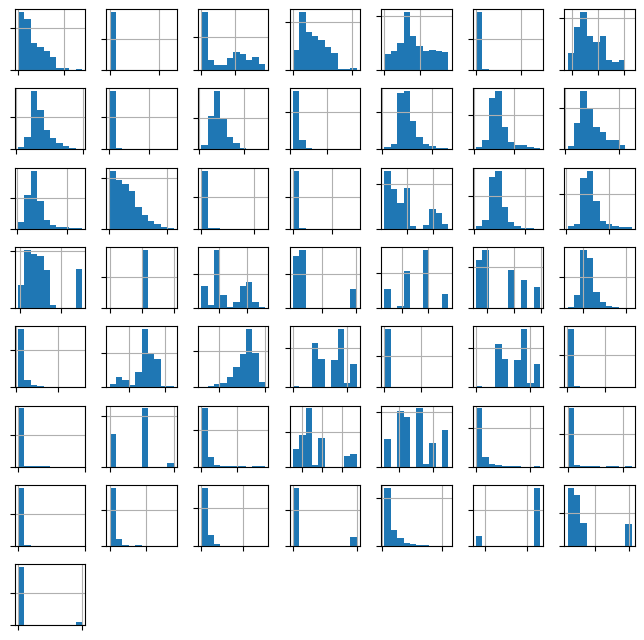

In [5]:
# Create a histogram of each feature.
%matplotlib inline 

ax = df.hist(figsize=(8,8))

# Disable axis labels to keep the plots uncluttered.
for axis in ax.flatten():
	axis.set_title('')
	axis.set_xticklabels([])
	axis.set_yticklabels([])
    
plt.show()

## Extract the data

In [6]:
X = df.values[:, : -1]
y = df.values[:, -1]

In [7]:
# Summarize the class distribution.
nrows, ncols = X.shape

print(f"Number of features: {ncols}")
print(f"Number of instances: {nrows}")

# Class 0 are the spill-free images and Class 1 are the images with spills.
counts = Counter(y)
for k,v in counts.items():
    percent = v / len(y)
    print(f'Class {k : .0f}: count = {v : d}, percentage = {percent : >7.3%}')

Number of features: 49
Number of instances: 937
Class  1: count =  41, percentage =  4.376%
Class  0: count =  896, percentage = 95.624%


# Data cleaning

We clean the data to remove problematic features.  Data cleaning will make the model less complex, which is a good thing.

## Remove sketchy features

As noted above, column 0 looks bogus, so let's remove it:

In [8]:
def drop_sketchy_features(X, drop):
    return np.delete(X, drop, axis=1)

In [9]:
drop = [0]
print(X.shape)
X = drop_sketchy_features(X, drop)
print(X.shape)

(937, 49)
(937, 48)


## Remove features with a single value

A single-valued feature cannot have any predictive power.

In [10]:
# Find and remove columns of features that take on only 1 value.
def remove_single_value_features(X, verbose=False):
    drop = []
    nrows, ncols = X.shape
    for k in range(ncols):
        S = set(X[:,k])
        if len(S) == 1:
            if verbose: 
                print(f"Column {k} takes on only the single value {S}!")
            drop += [k]
    if drop:
        if verbose: 
            print(f"...dropping columns {drop}...")
        X = np.delete(X, drop, axis=1)
    return X

In [11]:
print(X.shape)
X = remove_single_value_features(X)
print(X.shape)

(937, 48)
(937, 47)


## Remove features with one dominant value

Features that have a dominant value can be problematic.

Imagine a feature that is 0 for 95% of training cases.  Then the remaining 5% of training cases may have an undue influence on the model.

In [12]:
# Find and remove features with one dominant value.
#   1. The number of unique values over the sample is low (e.g., < 10%).
#   2. The ratio of the frequency of the most common value to next most common is large (e.g., 20). 
# See Section 3.5 of Kuhn and Johnson.

def remove_dominated_features(X, unique_values_tol = 0.1, ratio_tol = 20, verbose=False):
    nrows, ncols = X.shape
    drop = []
    for k in range(ncols):
        S = set(X[:,k])
        if len(S)/nrows < unique_values_tol:
            if verbose: 
                print(f"Column {k} has only {len(S)} unique values over {nrows} instances ({len(S)/nrows : .1%})!")
            drop += [k]
    if drop:
        if verbose:
            print(f"...dropping columns {drop}...")
        X = np.delete(X, drop, axis=1)

    nrows, ncols = X.shape  # X may have changed shape above.
    drop = []
    for k in range(ncols):
        count = Counter(X[:,k])
        count = sorted(count.values(), reverse=True)
        if count[0]/count[1] > ratio_tol:
            if verbose:
                print(f"In column {k} the most common value appears {count[0]} times while the secondmost appears {count[1]} times ({count[0]/count[1]})")
            drop += [k]
    if drop:
        if verbose:
            print(f"...dropping columns {drop}...")
        X = np.delete(X, drop, axis=1)
    return X

In [13]:
print(X.shape)
X = remove_dominated_features(X)
print(X.shape)

(937, 47)
(937, 28)


## Remove highly correlated features

In least-squares regression, highly correlated features can cause trouble since the normal matrix will be close to singular.  One solution is to remove correlated features, either through a heuristic or through PCA.

In classification, highly correlated features are less problematic.  However, redundant features add to the complexity of the model, and may add to the expense of collecting data.

In [14]:
# Plot the matrix of correlations between pairs of features.
def plot_corr_coeff(X, figsize=(10,10)):
    cm = np.corrcoef(X.T)
    plt.figure(figsize=figsize)
    sns.set(font_scale=1.0)
    sns.heatmap(cm, 
        cmap="coolwarm",
        cbar=True,
        annot=True, 
        square=True,
        fmt='.2f',
        annot_kws={'size': 6})
    
    plt.tight_layout()
    plt.show(block=False)

(937, 28)


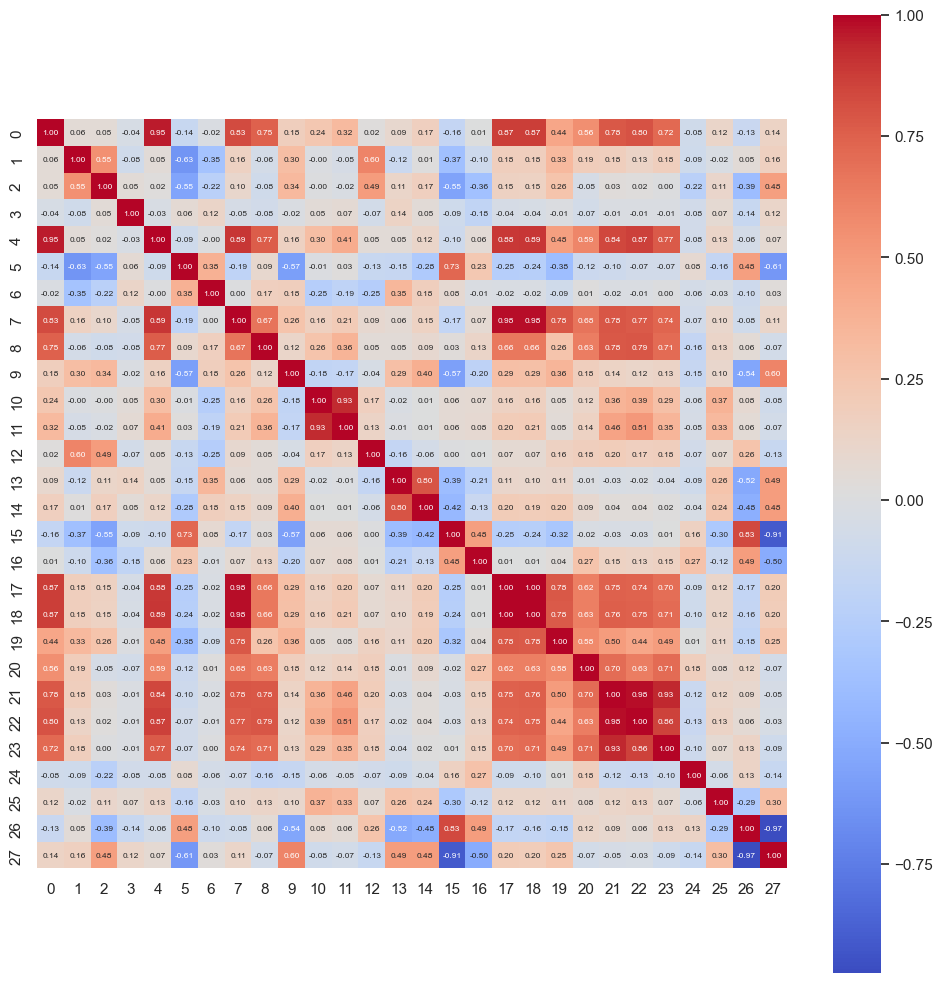

In [15]:
print(X.shape)
plot_corr_coeff(X)

We apply a heuristic for removing highly correlatd features.  This heuristic keeps the original features, whereas PCA produces linear combinations of features which might be difficult to understand.  On the other hand, PCA has a firm mathematical basis.

The heuristic is
1. Compute the correlation matrix of the features.
2. Find the two features with the largest absolute pairwise correlations.  Call these features $A$ and $B$.
    * If this absolute correlation is below a specified threshold, then stop.
4. Determine the average absolute correlation between $A$ and the other features.  Do the same for $B$.
5. Remove the feature with the higher average absolute correlation.
6. Repeat steps 2-4 until no absolute correlations are above the threshold.

In [16]:
# A heuristic for removing highly correlated features.
# See Section 3.5 of Kuhn and Johnson.

def remove_most_correlated_features(X, threshold=0.9):
    cm = np.abs(np.corrcoef(X.T))
    while np.max(np.triu(cm, k=1)) > threshold:  # Until we're happy with the correlations...
        # Find the two most correlated features.
        i, j = np.unravel_index(np.argmax(np.triu(cm, k=1)), cm.shape)

        # Of the two most correlated features, choose the one with the greater average 
        # absolute correlation with the others.
        sum_i = sum(np.abs(cm[i,:]))
        sum_j = sum(np.abs(cm[:,j]))
        k = i if sum_i > sum_j else j

        # Delete the most correlated feature.
        X = np.delete(X, k, axis=1)

        # Update the matrix of correlation coefficients.
        cm = np.delete(cm, k, axis=0)
        cm = np.delete(cm, k, axis=1)
    return X

(937, 28)
(937, 18)


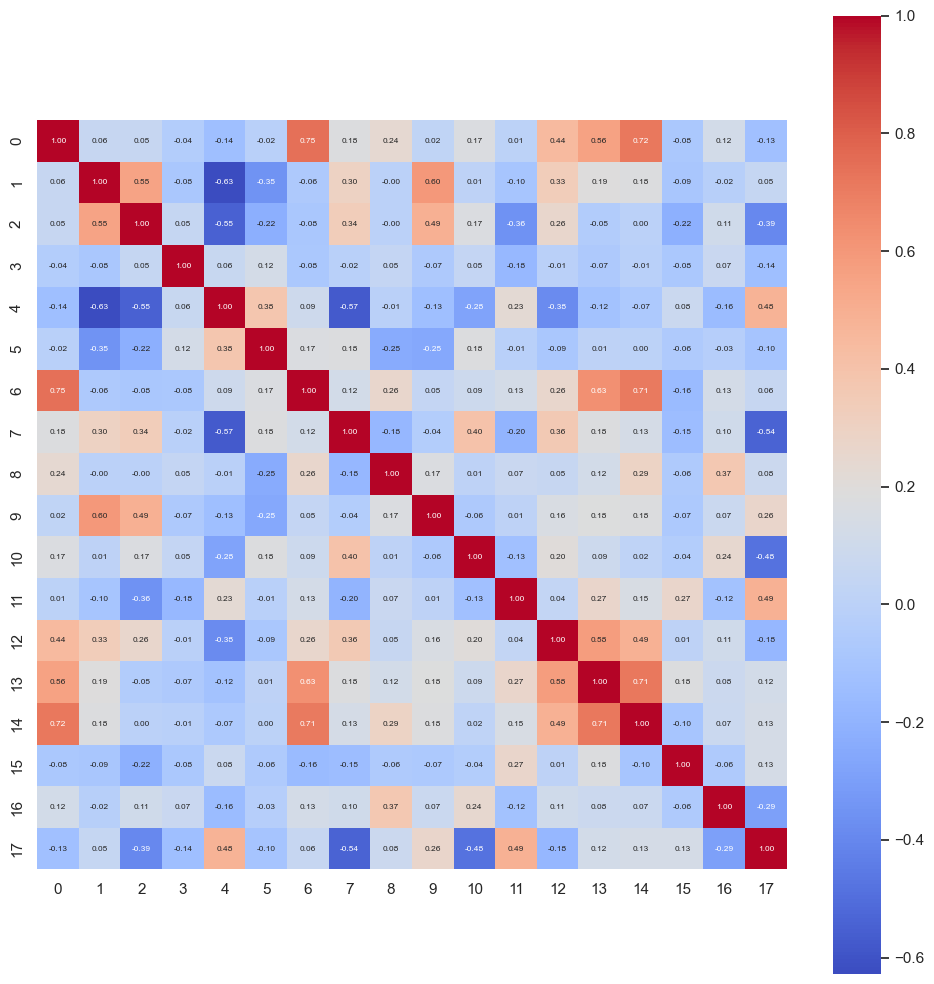

In [17]:
print(X.shape)
X = remove_most_correlated_features(X, threshold=0.75)
print(X.shape)
plot_corr_coeff(X)

## Apply PCA

As an alternative to the preceding heuristic we can apply PCA.

In [18]:
# Apply PCA with a specified threshold for the variance explained by the reduced model.

def apply_PCA(X, fraction=0.95, verbose=False):
    sc = StandardScaler().fit(X)  # If we don't scale then Bad Things happen.
    pca = PCA(n_components=fraction, svd_solver="full")  # Retain enough components to explain n_components fraction of the total variance.

    X = sc.transform(X)
    X = pca.fit_transform(X)

    if verbose:
        print(f"Number of components selected: {pca.n_components_}")
        print(f"Explained variance ratio (cumulative): {pca.explained_variance_ratio_.sum():.4f}")

    return X

In [19]:
print(X.shape)
X = apply_PCA(X)
print(X.shape)

(937, 18)
(937, 13)


# Functions to evaluate models

In [20]:
# Evaluate a model using cross-validation.  
#
# Because the dataset is highly imbalanced (96% - 4%), accuracy is a terrible evaluation metric since
# the majority classifier would have an accuracy of 96%.
#
# Instead we will use the geometric mean of the class sensitivities:
#    sqrt(true negative rate * true positive rate).
# This balances getting both classes right.  The geometric mean is more sensitive to the balance of 
# accuracy across the classes than is the arithmetic average (the harmonic mean would be even more so).

def evaluate_model(model, X, y, n_splits=10, n_repeats=3, random_state=42):
    # Specify the evaluation procedure.
    cv = sk.model_selection.RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)

    # Specify the model evaluation metric.
    metric = sk.metrics.make_scorer(geometric_mean_score)

    # Evaluate the model.
    scores = sk.model_selection.cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
    return scores

In [21]:
# Evaluate models and present the results as a boxplot.

def evaluate_models(models, X, y, figsize=(10,10)):
    results = []
    print(f"{'model':16} {'mean':8} {'std dev':8}   {'median':8} {'IQR':8}")
    for name, model in models.items():
        scores = evaluate_model(model, X, y)
        results.append(scores)
        p25, p75 = np.percentile(scores, [25, 75])
        iqr = p75 - p25
        print(f"{name:16} {np.mean(scores):8f} {np.std(scores):8f}   {np.median(scores):8f} {iqr:8f}")
    plt.figure(figsize=figsize)
    plt.boxplot(results, tick_labels=models.keys(), showmeans=True)
    plt.ylabel("Geometric mean score")
    plt.show(block=False)

In [22]:
# Plot the ROC and DET curves

# Stolen from https://scikit-learn.org/stable/auto_examples/model_selection/plot_det.html
# and hacked up.

# ROC = Receiver Operating Characteristics
# DET = Detection Error Tradeoff

def ROC_DET_curves(models, X, y):
    baseline = DummyClassifier()  # Used to draw the 45° line of a baseline model.
    baseline.fit(X, y)

    cv = sk.model_selection.RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=42)
    for name, model in models.items():
        fig, [ax_roc, ax_det] = plt.subplots(1, 2, figsize=(11, 5))
        ax_roc.set_title(f"{name} ROC curves")
        ax_det.set_title(f"{name} DET curves")
        ax_roc.grid(linestyle="--")
        ax_det.grid(linestyle="--")
        RocCurveDisplay.from_estimator(baseline, X, y, ax=ax_roc, name="Baseline")
        DetCurveDisplay.from_estimator(baseline, X, y, ax=ax_det, name="Baseline")    
        for (train, test) in cv.split(X, y):
            X_train = X[train,:]
            y_train = y[train]
            X_test  = X[test,:]
            y_test  = y[test]

            model.fit(X_train, y_train)
        
            RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax_roc, name=name)
            DetCurveDisplay.from_estimator(model, X_test, y_test, ax=ax_det, name=name)
        plt.legend()
        plt.show()

# Construct a baseline model.

In [23]:
# Define a baseline model.
model = sk.dummy.DummyClassifier(strategy='uniform')

# Evaluate the model and report.
scores = evaluate_model(model, X, y)
print(f"Geometric mean scores:\n {scores}")
print(f"Arithmetic mean of geometric means: {np.mean(scores)}")

Geometric mean scores:
 [0.43961168 0.4772607  0.65192024 0.36132472 0.32489314 0.61913919
 0.36132472 0.31799936 0.51385304 0.51929079 0.57474958 0.65828059
 0.         0.         0.63245553 0.76739096 0.38369548 0.58058475
 0.60892242 0.45592233 0.55687733 0.48876261 0.35746018 0.53229065
 0.36514837 0.49441323 0.35355339 0.52467218 0.47993445 0.59492233]
Arithmetic mean of geometric means: 0.46655513188280506


# What you are to do

In the following code we use different flavors of Logistic Regression as our classifier.  You are to repeat the experiments with different classifiers.

You should try to get decent results but there is no need to spend a lot of time tuning the classifiers.
 
You should begin with a summary of your work.

General questions to address include:
* What happens when you combine class weighting with SMOTE?
* Which was better: class weighting better, data augmentation via SMOTE, or a combination of the two?
* Were there any surprises along the way?

Each experiment has other questions for you to address.

# What you are to submit

* Submit a Jupyter notebook named <code>imbalanced.ipynb</code> that shows your work and contains the code and commentary.

# Your observations

Your observations go here.  
**Experiment 1:** 
* How did the classifiers perform?  
The linear regression classifiers actually performed better than the SVM ones. The unbalanced ones consistently performed worse than the balanced ones although for the balanced ones the difference between classifiers was much smaller. For LR all the balanced ones were similar but interestingly the normal balanced was considerably lower performing using SVM than the norm or std ones. The only other notable thing is that the SVM unbalanced and generic balanced were not only simliar but the exact same data wise.    
* Did data cleaning cause the models to improve or deteriorate?  
There was no actual data cleaning done in this first experiment. 
* What happens when you combine class weighting with SMOTE?  
The first experiment doesn't actually use SMOTE so there isn't a way to see what combining it would do.
* Which was better: class weighting better, data augmentation via SMOTE, or a combination of the two?  
Class weighting was the only thing that happened in this experiment but it did actually improve the data so it would be the best for what we saw. Balancing the classes out caused the all of the different data points recorded to increase and improve. 
* Were there any surprises along the way?  
My first thought was that SVM's were going to improve it but after actually thinking about it more it makes sense that it didn't directly improve. The other thing was the large gap from the SVM basic balanced classifier I thought it would be like the LR ones and similar to the other two but it wasn't at all.  
Edit: i realized I shouldn't have had a linear kernel being applied to the generic balanced one and after removal it ends up being in between the two unbalanced and special balanced groups.
Lies around the 70s range. 


**Experiment 2:**  
* How did the classifiers perform?  
The first two did fairly similar with slight variations but it didn't seem like a clear improvement or deprovement. The same observations apply where the linear did marginally better. However after many many tries nothing made it so that the RCF could keep up, it is always considerably worse than the other two. It ranged from 40 points back and then after refinement landed at about 20 points behind the other two. 
* Did data cleaning cause the models to improve or deteriorate?   
I would say overall data cleaning was an improvement and logically that would make sense although it was fairly uneven across the different classifiers. It did noticebly improve the graphical statistics on the curves although even those numbers weren't sizeable. 
* An interpretation of your ROC and DET curves.   
These reiterate the mean statistics in showing a massive improvement from unbalanced to any form of balanced especially the balanced-normalized has really strong ROC curves. The AUC values seem to be stabilizing around the high 80s to low 90s around the 88-92 range. The DET curves tend to reiterate all of this information as the balanced models have far lower false negative rates. 
* What happens when you combine class weighting with SMOTE?  
Once again no SMOTE was used in this and it was solely class weighting except now with some data cleaning.  
* Which was better: class weighting better, data augmentation via SMOTE, or a combination of the two?  
The only option for this is class weighting as it was the only one used. 
* Were there any surprises along the way?   
Yeah I thought RCF would do way better and looking back after finishing the other two parts of the final it still suprises me just how bad it is. I assume it is due to the lack of features in comparison but it still suprises me.  


**Experiment 3:** 
* How did the classifiers perform?
All of them did fairly similar to the previous but definitely better by a few percente points each. I think the more clear thing I noticed was the consistency/stability. All of the numbers are pretty similar and whenever changes were put in there was never a time where one wildly diverged like in the other scenarios. The AUC values were still very high but also noticebly more together with less high 80s and more low 90s all very close together. Same thing could be seen with the DET curves also. 
* Did data cleaning cause the models to improve or deteriorate? 
I think it was definitely an improvement here on all fronts. While nothing improved by like 20 points everything got small but noticeble improvements.  
(i removed the SMOTE questions because once again it wasn't used)  
* Were there any surprises along the way?  
I think I was expecting a slightly bigger improvement then what was seen but other than that no.


**Experiment 4:**  
* What happens when you combine class weighting with SMOTE?  
It actually let do worsening results and a clear negative impact. The logistical regression classifier had better slightly better table results but also slightly worse graphic results. There was no obvious ruining of the classifiers but it definitely wasnt an overall help either.  
* Which was better: class weighting better, data augmentation via SMOTE, or a combination of the two?  
Purely class weighting is definitely the best and combination is definitely the worst. Pretty much across the aboard this statement follows true, the benefits were seen through the entire analysis and were mostly consistent when it came to class weighting. 
* Were there any surprises along the way?  
You would think the more you add and the more agressive the training the better but obviously over training and over fitting is a factor which came through here. 
* Which was better: class weighting better or data augmentation via SMOTE?  
Same as part 3.

**Experiment 5:**  
* Discuss how changing the <code>sampling_strategy</code> in <code>SMOTEEEN</code> affects the results.  
Minority wasn't working for me but when I used not majority it actually made it worse and then when I used all it was really similar to the majority. I think not majority was worse because the majority class is much bigger so the data being resampled is smaller so the impact it has will be lower. All resampling being similar to majority also makes sense because it is essentially just resampling the majority because it is so much bigger.
* What happens when you combine class weighting with SMOTE?  
As we have consistantly seen logistical regression was better and in this scenario started much lower than the other tests but ended slightly higher. SVC was worse but followed a similar path of improvement over the iterations. As the percent got higher with the SMOTE tests so did the table based data for both classifiers. 
* Which was better: class weighting better, data augmentation via SMOTE, or a combination of the two?  
Just like in the previous experiment class weighting alone would be the best as combining them makes a mess of things and only using SMOTE is slightly worse than just going with class weighting. The SMOTE alone is really dependent on choosing the best class for the scenario and if you chose minority/notmajority in this scenario its clearly worse. Class weighting is just more consistant and even when the best is chosen for SMOTE it is pretty similar regardless.
* Were there any surprises along the way?  
I didn't realize how important choosing majority/the correct sampling strategy was going to be but it definitely makes sense. 



# Address imbalance by class weighting

With class weighting we amplify the effect of the minority class in the metric we are using during training.

## To do

Repeat Experiments 1-3.

In [103]:
def run_models(X, y):
    models = {}

    # LR unbalanced
    models["Unbalanced"] = LogisticRegression(random_state=42, max_iter=500, solver='liblinear')

    # LR balanced
    models["Balanced"] = LogisticRegression(random_state=42, max_iter=500, solver='liblinear', class_weight='balanced')

    # LR balanced + normalization
    models["Balanced-norm"] = Pipeline(
        steps=[
            ('t', MinMaxScaler()),
            ('m', LogisticRegression(random_state=42, max_iter=500, solver='liblinear', class_weight='balanced'))
        ]
    )

    # LR balanced + standardization
    models["Balanced-std"] = Pipeline(
        steps=[
            ('t', StandardScaler()),
            ('m', LogisticRegression(random_state=42, max_iter=500, solver='liblinear', class_weight='balanced'))
        ]
    )

    evaluate_models(models, X, y)
    ROC_DET_curves(models, X, y)
   

In [ ]:
from sklearn.svm import SVC

def experiment_1(X, y):
    models = {}
    
     # LR unbalanced
    models["Unbalanced"] = SVC(kernel = 'linear', random_state=42, max_iter=1000, probability=True)

    # LR balanced
    models["Balanced"] = SVC(random_state=42, max_iter=1000, class_weight='balanced', probability=True)
    
    models["Balanced-norm"] = Pipeline(
        steps=[
            ('t', MinMaxScaler()),
            ('m', SVC(
                kernel='linear', max_iter=1000, random_state=42, class_weight='balanced', probability=True
            ))
        ]
    )

    # SVM balanced + standardization
    models["Balanced-std"] = Pipeline(
        steps=[
            ('t', StandardScaler()),
            ('m', SVC(kernel='linear',max_iter=1000, random_state=42, class_weight='balanced', probability=True
            ))
        ]
    )
    

    evaluate_models(models, X, y)
    ROC_DET_curves(models, X, y)

In [133]:
def experiment_2SVC(X, y):
    models = {}
    
     # LR unbalanced
    models["Unbalanced"] = SVC(kernel = 'linear', random_state=42, max_iter=1000, probability=True)

    # LR balanced
    models["Balanced"] = SVC(random_state=42, max_iter=1000, class_weight='balanced', probability=True)
    
    models["Balanced-norm"] = Pipeline(
        steps=[
            ('t', MinMaxScaler()),
            ('m', SVC(
                kernel='linear', max_iter=1000, random_state=42, class_weight='balanced', probability=True
            ))
        ]
    )

    # SVM balanced + standardization
    models["Balanced-std"] = Pipeline(
        steps=[
            ('t', StandardScaler()),
            ('m', SVC(kernel='linear',max_iter=1000, random_state=42, class_weight='balanced', probability=True
            ))
        ]
    )
    

    evaluate_models(models, X, y)
    ROC_DET_curves(models, X, y)

In [138]:
from sklearn.ensemble import RandomForestClassifier

def experiment_2RFC(X, y):
    models = {}
    
     # LR unbalanced
    models["Unbalanced"] = RandomForestClassifier(n_estimators=500, max_depth=50, min_samples_split=10, min_samples_leaf=5, n_jobs=-1, random_state=42)

    # LR balanced
    models["Balanced"] = RandomForestClassifier(n_estimators=500, max_depth=50, min_samples_split=10, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=42)
    
    models["Balanced-norm"] = Pipeline(
        steps=[
            ('t', MinMaxScaler()),
            ('m', RandomForestClassifier(
                n_estimators=500, max_depth=50, min_samples_split=10, min_samples_leaf=5, class_weight="balanced", n_jobs =-1, random_state=42
            ))
        ]
    )

    # SVM balanced + standardization
    models["Balanced-std"] = Pipeline(
        steps=[
            ('t', StandardScaler()),
            ('m', RandomForestClassifier(n_estimators=500, max_depth=50, min_samples_split=10, min_samples_leaf=5, class_weight="balanced",n_jobs =-1, random_state=42
            ))
        ]
    )
    

    '''
    first tried to just replace Randomforestclassifier over svc but did not work. tinkering a lot with the values, last three always the same except once but i think i messed something up.
    lowering the min sample interestingly actually raised the first unabalanced one but not the rest. Im stuck in the 60s? Unbalanced now 0 for everything after increasing min sample leaf. 
    Only thing that noticebly makes it better is increasing estimators but that makes it a lot longer. Even when boosting the depth and estimators quite a bit it still looks to be centered around
    the 60s area. Tried no max depth still didn't improve past 60s. I accidently had jobs on -1 instead of 1 but it didn't do anything after fixing. I think it is actually supposed to be -1 so im
    switching back even if its pointless. Tinkered with the random_state but still hovered around the same numbers. 42 is slightly higher than 1 and its what the others use so going to stick
    with it. 
    '''
    evaluate_models(models, X, y)
    ROC_DET_curves(models, X, y)

## Experiment 1: Without any data cleaning.

We use the original dataset without any data cleaning.

**Repeat this experiment replacing the Logistic Regression classifier with an SVM.**

Your summary should address:
* How did the classifiers perform?
* Did data cleaning cause the models to improve or deteriorate?

model            mean     std dev    median   IQR     
Unbalanced       0.605766 0.259488   0.663839 0.340325
Balanced         0.859102 0.098351   0.862644 0.121791
Balanced-norm    0.837544 0.107177   0.831665 0.126010
Balanced-std     0.845804 0.113431   0.841486 0.115847


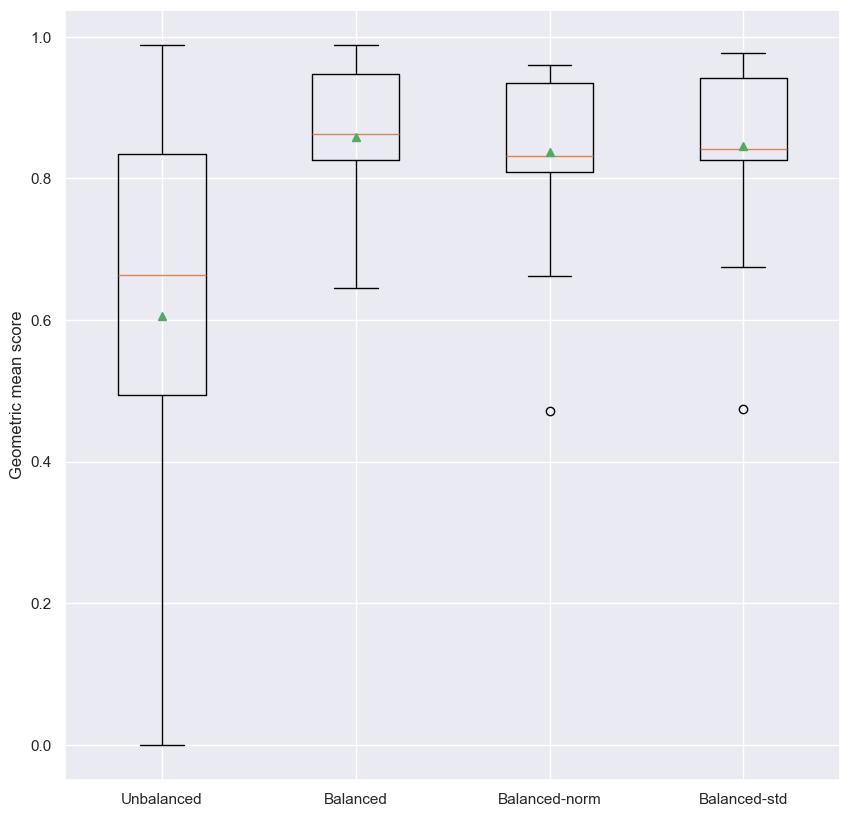

model            mean     std dev    median   IQR     
Unbalanced       0.218929 0.228690   0.170851 0.478600
Balanced         0.218929 0.228690   0.170851 0.478600
Balanced-norm    0.827369 0.111566   0.828955 0.104349
Balanced-std     0.806129 0.138315   0.826640 0.109921


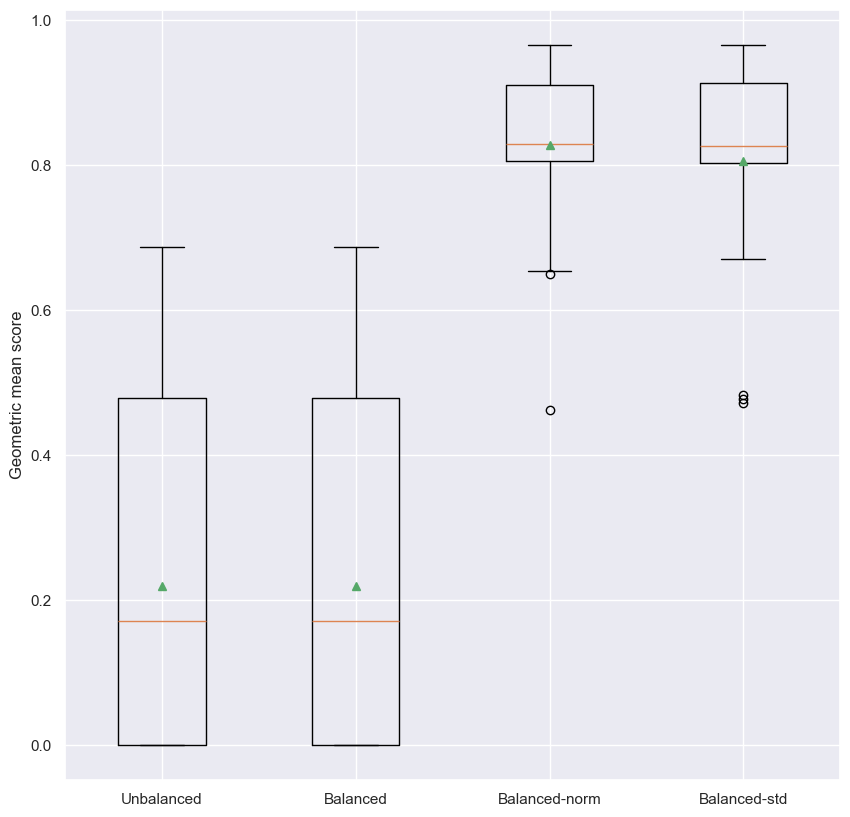

In [47]:
X = df.values[:, : -1]
y = df.values[:, -1]

run_models(X, y)
experiment_1(X, y)

## Experiment 2: With data cleaning (no PCA)

The dataset goes through data cleaning but **without** PCA.

**Repeat this experiment replacing the Logistic Regression classifier with an SVM *and* a Random Forest.**

Your summary should address:
* How did the classifiers perform?
* Did data cleaning cause the models to improve or deteriorate?
* An interpretation of your ROC and DET curves.

(937, 49)
(937, 18)
model            mean     std dev    median   IQR     
Unbalanced       0.565818 0.302241   0.672699 0.539977
Balanced         0.786546 0.121231   0.790125 0.135775
Balanced-norm    0.819937 0.099673   0.819040 0.111404
Balanced-std     0.849078 0.077651   0.824112 0.129909


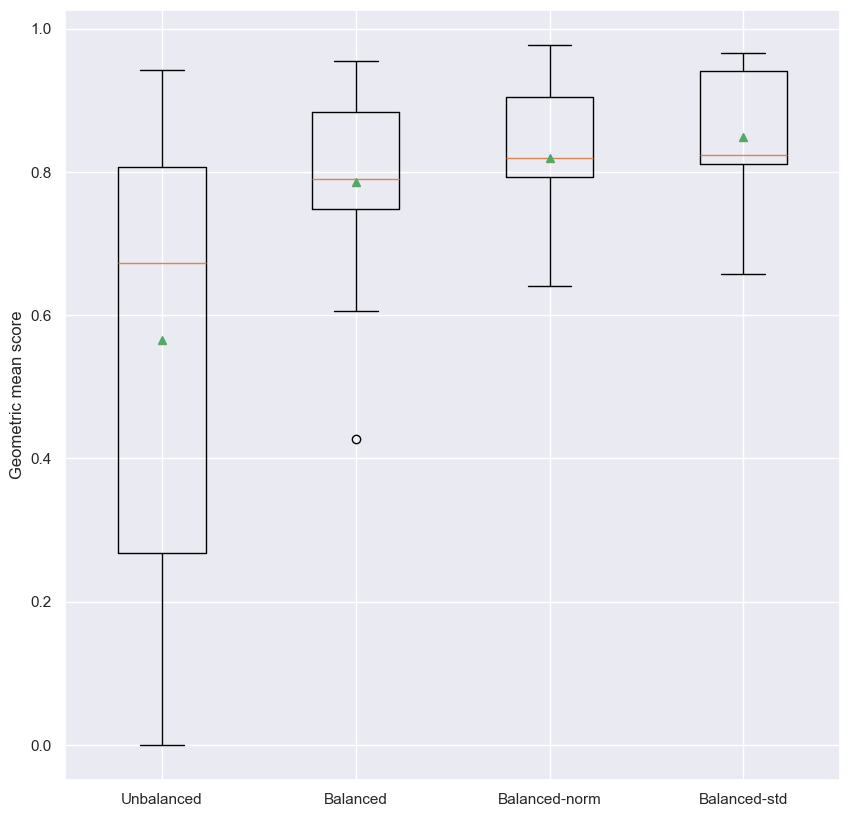

c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm

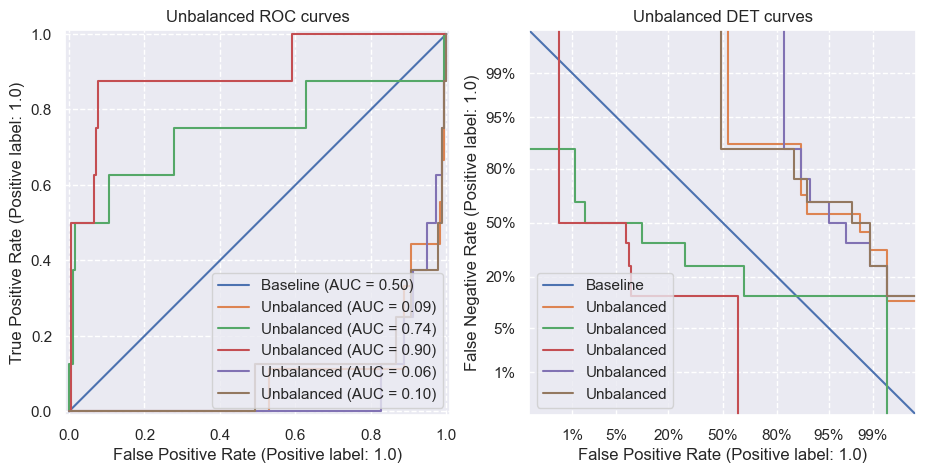

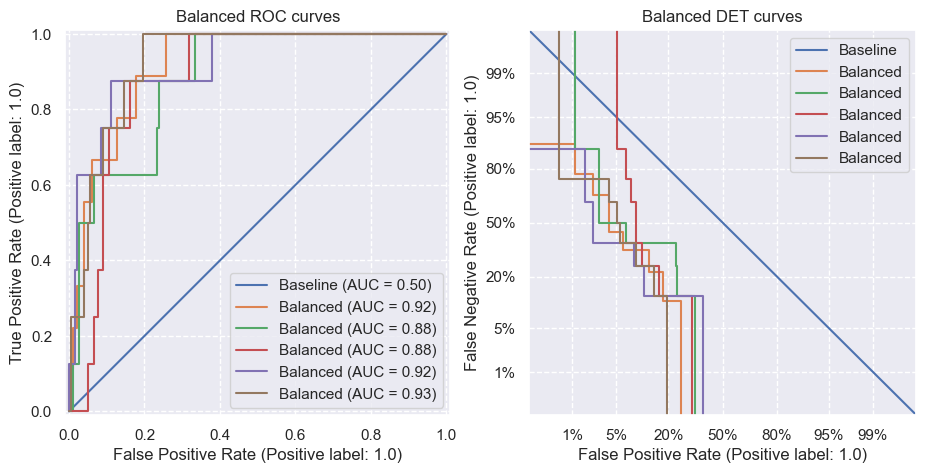

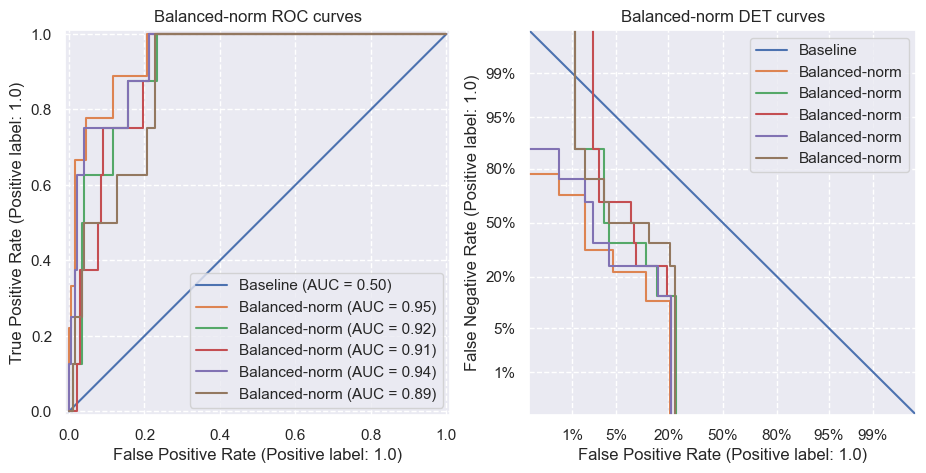

c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm

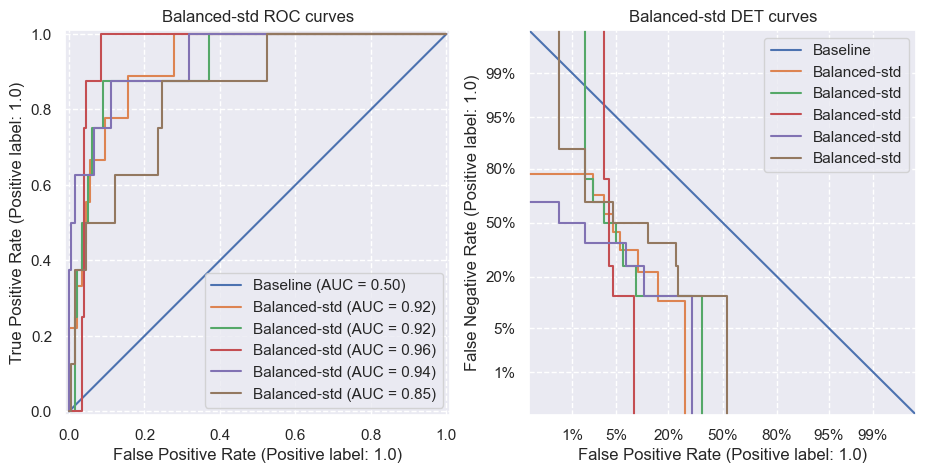

In [ ]:
X = df.values[:, : -1]
y = df.values[:, -1]

print(X.shape)
X = drop_sketchy_features(X, [0])
X = remove_single_value_features(X)
X = remove_dominated_features(X)
X = remove_most_correlated_features(X, threshold=0.75)
print(X.shape)

#run_models(X, y)
experiment_2SVC(X, y)
experiment_2RFC(X, y)

## Experiment 3: With data cleaning (only PCA)

We skip all the data cleaning **except** for PCA.

Repeat this experiment with an SVM.

Your summary should address:
* How did the classifiers perform?
* Did data cleaning cause the models to improve or deteriorate?

(937, 49)
(937, 18)
model            mean     std dev    median   IQR     
Unbalanced       0.574540 0.152817   0.500000 0.204929
Balanced         0.835302 0.096221   0.821584 0.112488
Balanced-norm    0.843137 0.113506   0.826413 0.129274
Balanced-std     0.836182 0.095858   0.821584 0.112400


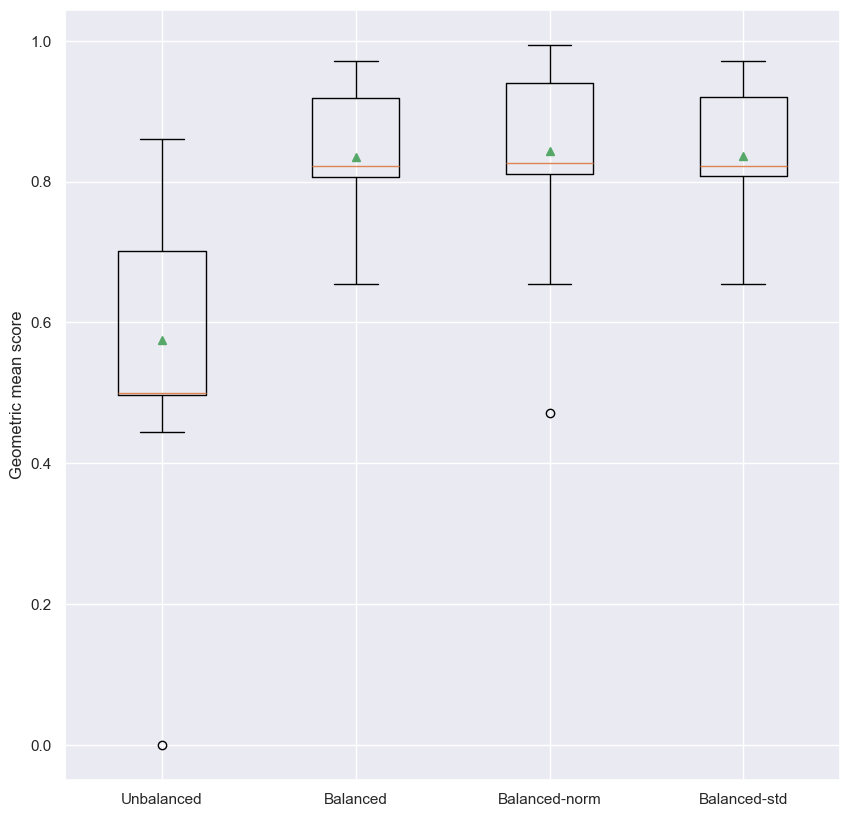

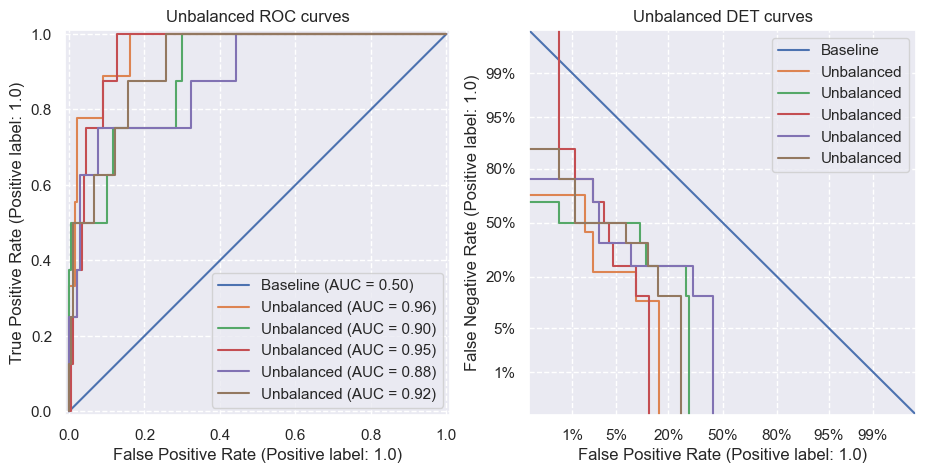

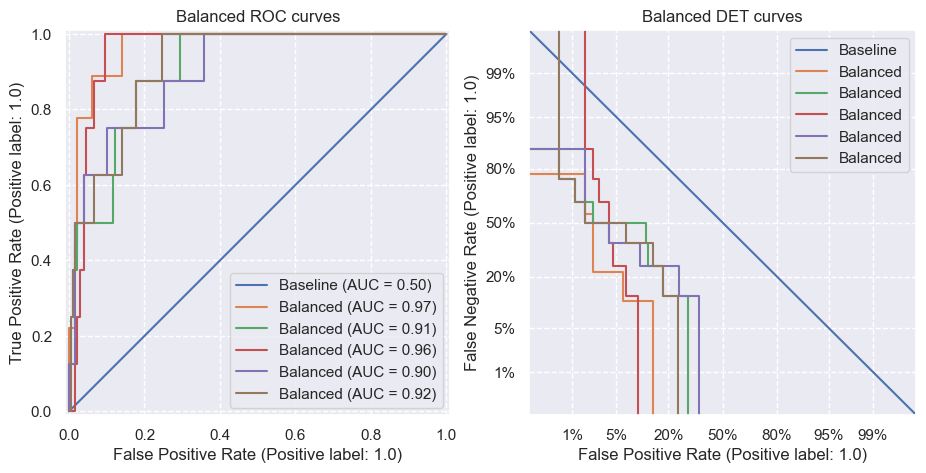

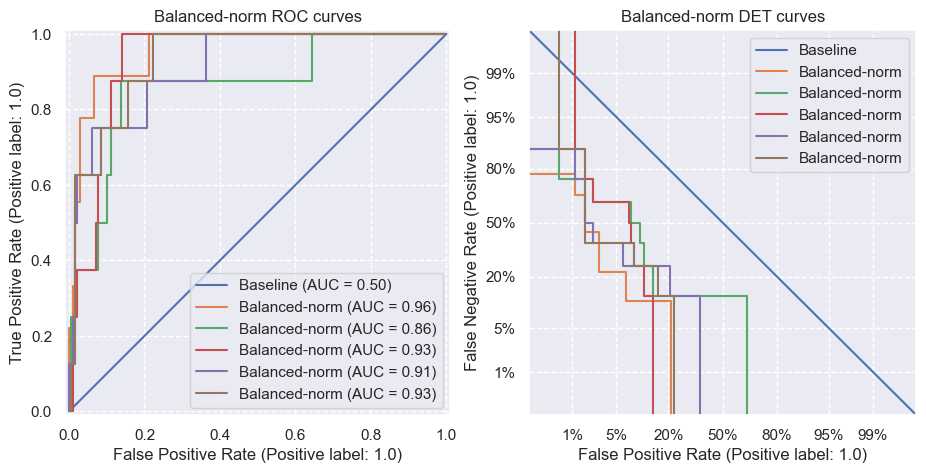

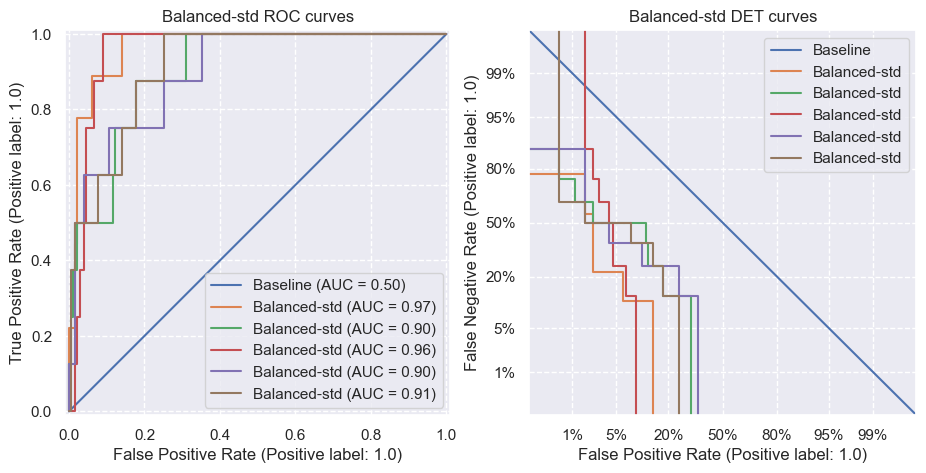

model            mean     std dev    median   IQR     
Unbalanced       0.542048 0.242715   0.595607 0.210867
Balanced         0.774861 0.133832   0.818753 0.172838
Balanced-norm    0.831424 0.102414   0.821584 0.112400
Balanced-std     0.811134 0.109819   0.811060 0.117066


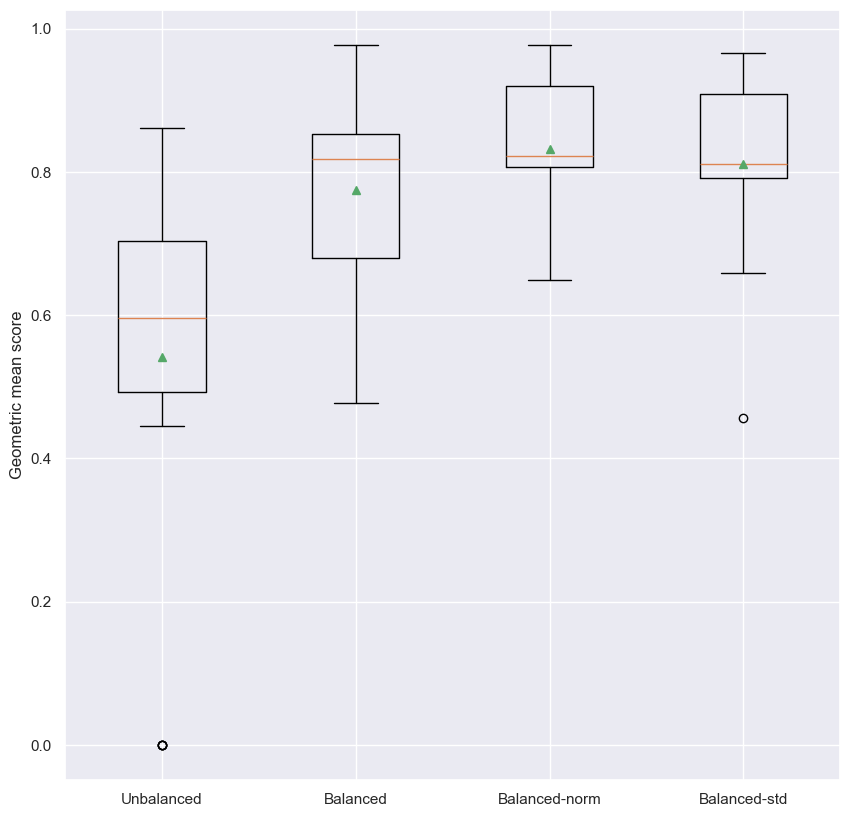

c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm

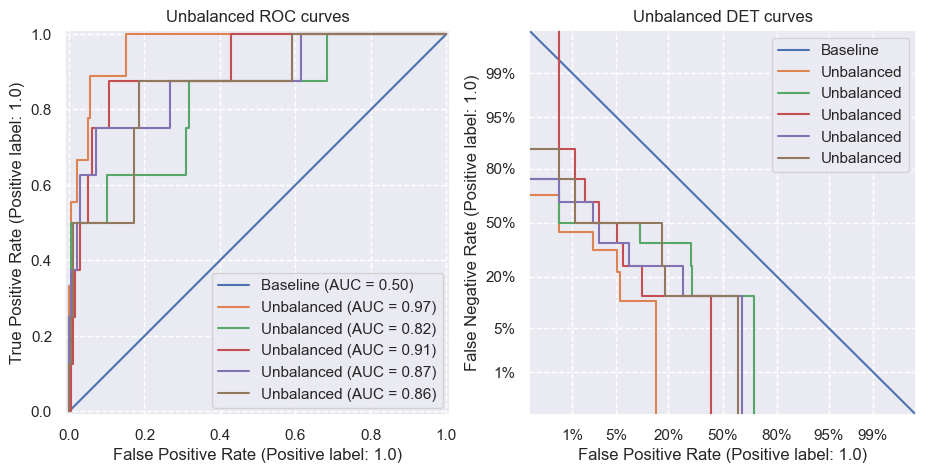

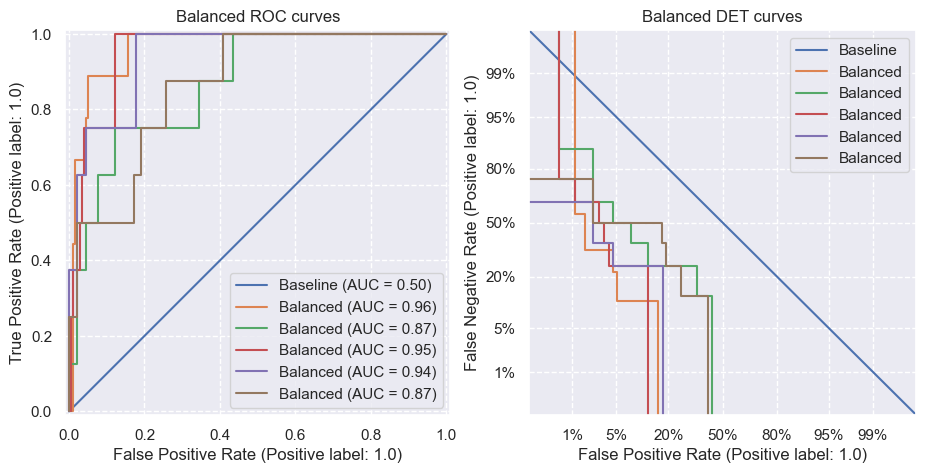

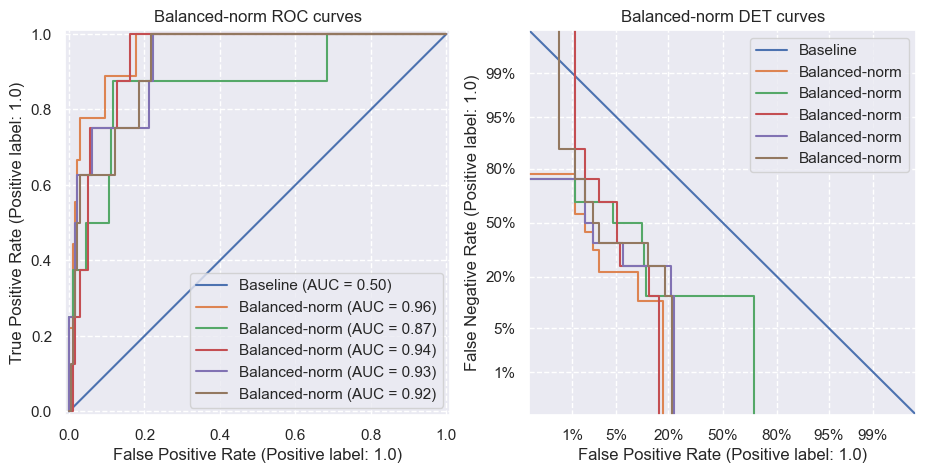

c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Aidan\Downloads\project\.venv\lib\site-packages\sklearn\svm

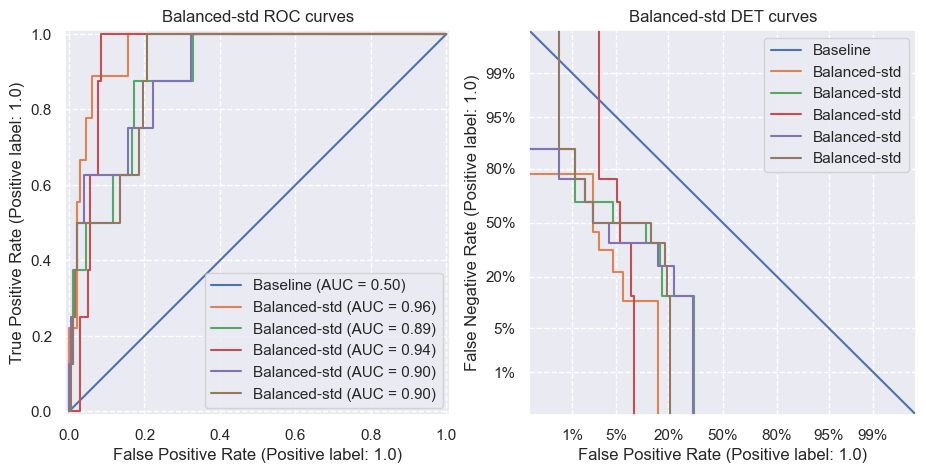

In [136]:
X = df.values[:, : -1]
y = df.values[:, -1]

print(X.shape)
X = apply_PCA(X)
print(X.shape)

run_models(X, y)
experiment_2SVC(X, y) # i think i can just use the same SVC?

# Address imbalance by augmenting the data

We examine two approaches:
* synthesize new minority instances via Synthetic Minority Oversampling Technique (SMOTE);
* pruning the majority instances using edited nearest neighbors.

SMOTE creates new instances by interpolating between nearby members of the minority class.

Edited nearest neighbors (ENN) prunes the majority class by removing instances close to the decision boundary.  In binary classification ENN does so by removing majority class members when most of its closest neighours are from the minority class.

## To do

Repeat Experiments 4-5.

## Experiment 4

**Repeat this experiment with an SVM.**

In your summary, discuss
* Which was better: class weighting better or data augmentation via SMOTE?

model            mean     std dev    median   IQR     
SMOTE            0.813985 0.118268   0.826640 0.159280
LR               0.821210 0.109955   0.823885 0.094290
Norm             0.835559 0.102940   0.826624 0.108237
Std              0.844593 0.082742   0.826624 0.110941


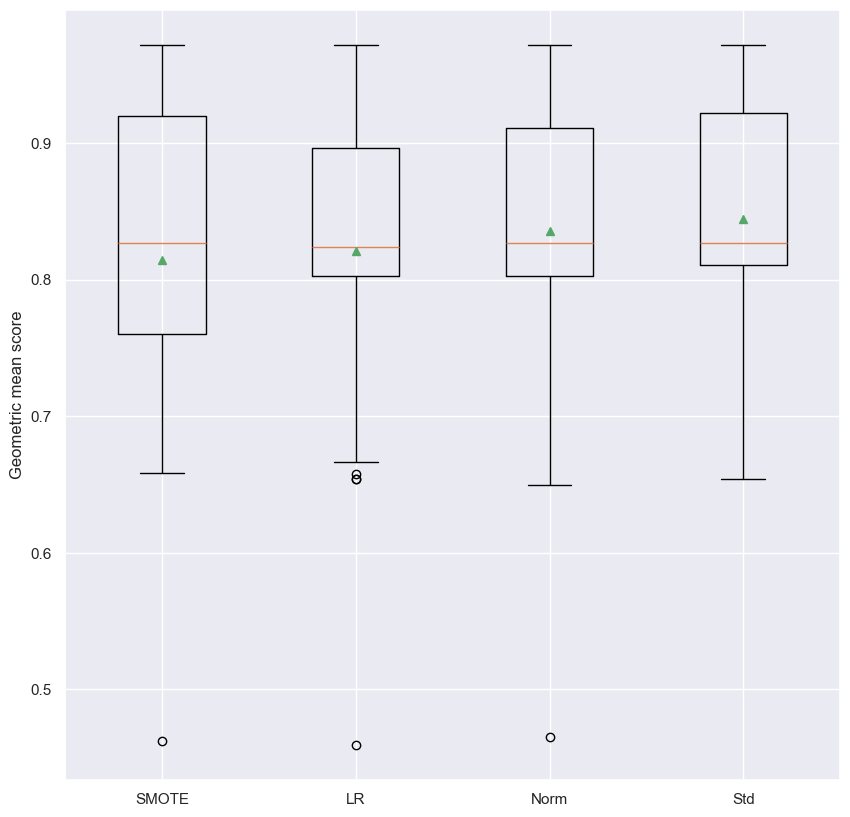

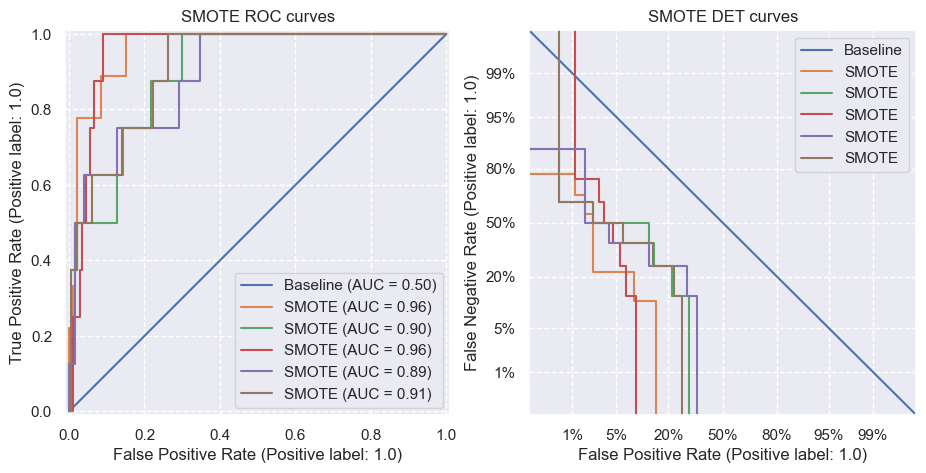

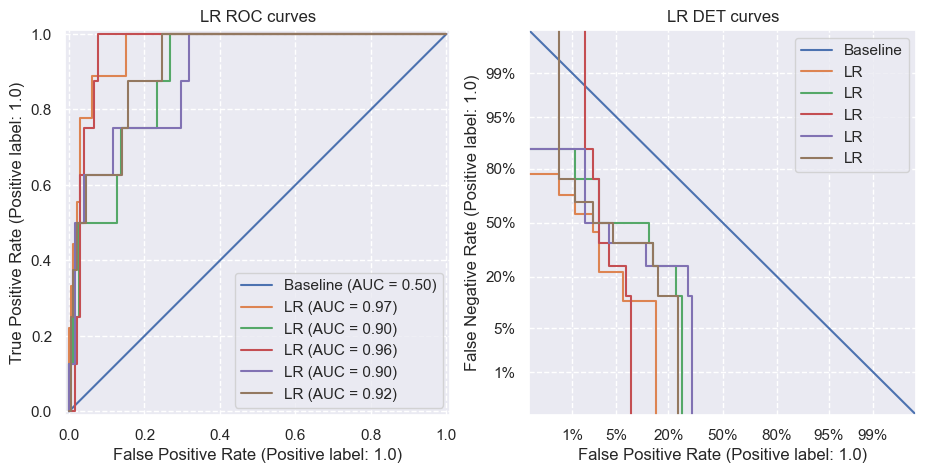

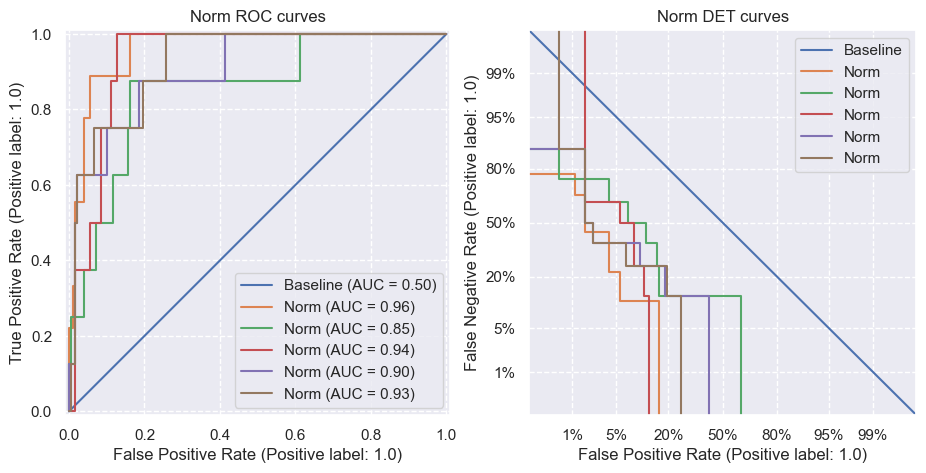

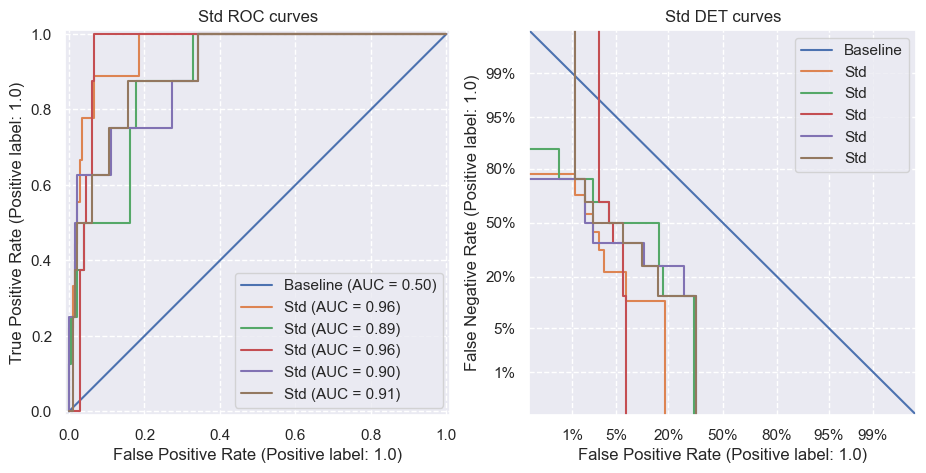

In [139]:
models = {}

models["SMOTE"] = Pipeline(
    steps=[
        ('SMOTE', SMOTE(random_state=42)),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
    ])

# SMOTEENN
models["LR"] = Pipeline(
    steps=[
        ('e', SMOTEENN(enn=EditedNearestNeighbours(sampling_strategy='majority'))),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
    ])

# SMOTEENN + normalization
models["Norm"] = Pipeline(
    steps=[
        ('t', MinMaxScaler()),
        ('e', SMOTEENN(enn=EditedNearestNeighbours(sampling_strategy='majority'))),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
    ])

# SMOTEENN + standardization
models["Std"] = Pipeline(
    steps=[
        ('t', StandardScaler()),
        ('e', SMOTEENN(enn=EditedNearestNeighbours(sampling_strategy='majority'))),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
    ])

evaluate_models(models, X, y)
ROC_DET_curves(models, X, y)

model            mean     std dev    median   IQR     
SMOTE            0.521546 0.268156   0.585708 0.478548
SVM              0.417069 0.324127   0.371677 0.561452
Norm             0.811566 0.114273   0.808453 0.227808
Std              0.840582 0.089859   0.821584 0.138468


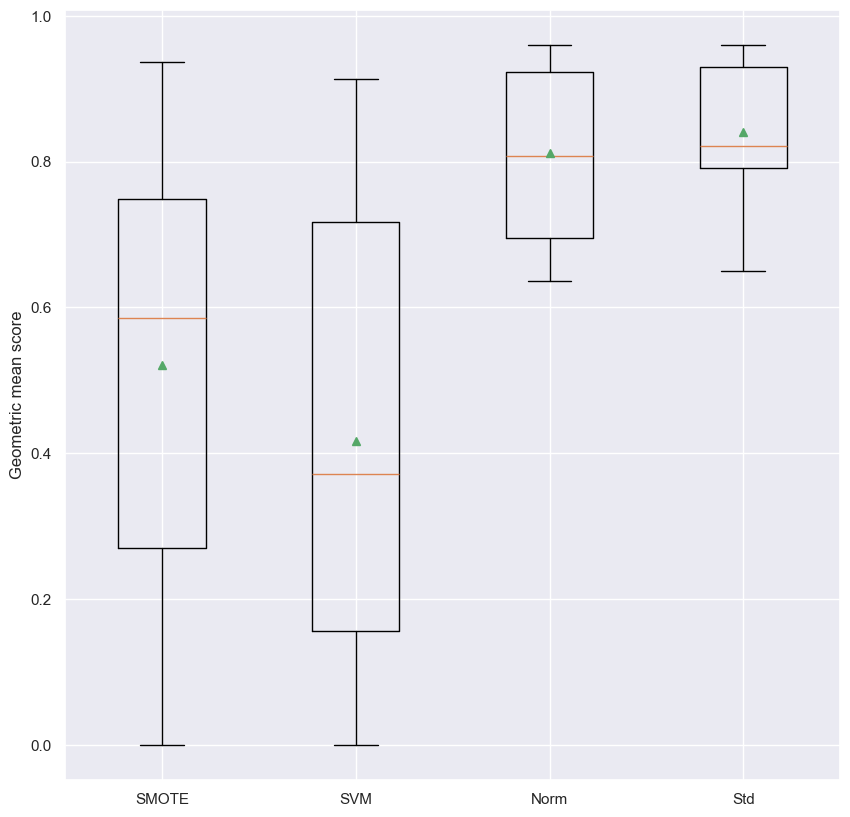

In [ ]:
models = {}

# SMOTE + SVM
models["SMOTE"] = Pipeline(
    steps=[
        ('s', SMOTE(random_state=42)),
        ('m', SVC(kernel='linear', probability=True, max_iter=1000, random_state=42
        ))
    ]
)

# SMOTEENN + SVM
models["SVM"] = Pipeline(
    steps=[
        ('e', SMOTEENN(
            enn=EditedNearestNeighbours(sampling_strategy='majority'),
            random_state=42
        )),
        ('m', SVC(kernel='linear',probability=True, max_iter=1000,random_state=42
        ))
    ]
)

# SMOTEENN + normalization + SVM
models["Norm"] = Pipeline(
    steps=[
        ('t', MinMaxScaler()),
        ('e', SMOTEENN(
            enn=EditedNearestNeighbours(sampling_strategy='majority'),
            random_state=42
        )),
        ('m', SVC(kernel='linear', probability=True, max_iter=1000, random_state=42
        ))
    ]
)

# SMOTEENN + standardization + SVM
models["Std"] = Pipeline(
    steps=[
        ('t', StandardScaler()),
        ('e', SMOTEENN(
            enn=EditedNearestNeighbours(sampling_strategy='majority'),
            random_state=42
        )),
        ('m', SVC(kernel='linear', probability=True, max_iter=1000, random_state=42
        ))
    ]
)

evaluate_models(models, X, y)

## Experiment 5

Construct multiple models by varying the extent to which we oversample the minority class and undersample the majority class.

**Repeat this experiment with an SVM.**

In your summary, 
* discuss how changing the <code>sampling_strategy</code> in <code>SMOTEEEN</code> affects the results.

model            mean     std dev    median   IQR     
Default          0.856442 0.083043   0.831650 0.123227
0.1              0.762012 0.142286   0.770220 0.164139
0.2              0.770614 0.135018   0.805460 0.163323
0.3              0.782113 0.141586   0.831271 0.172376
0.4              0.823233 0.134685   0.831665 0.127300
0.5              0.820218 0.132883   0.829152 0.134210
0.6              0.832418 0.112509   0.829152 0.129853
0.7              0.842563 0.110132   0.836448 0.123832
0.8              0.848338 0.108091   0.833906 0.130337
0.9              0.852754 0.088521   0.833906 0.135513
1.0              0.856442 0.083043   0.831650 0.123227


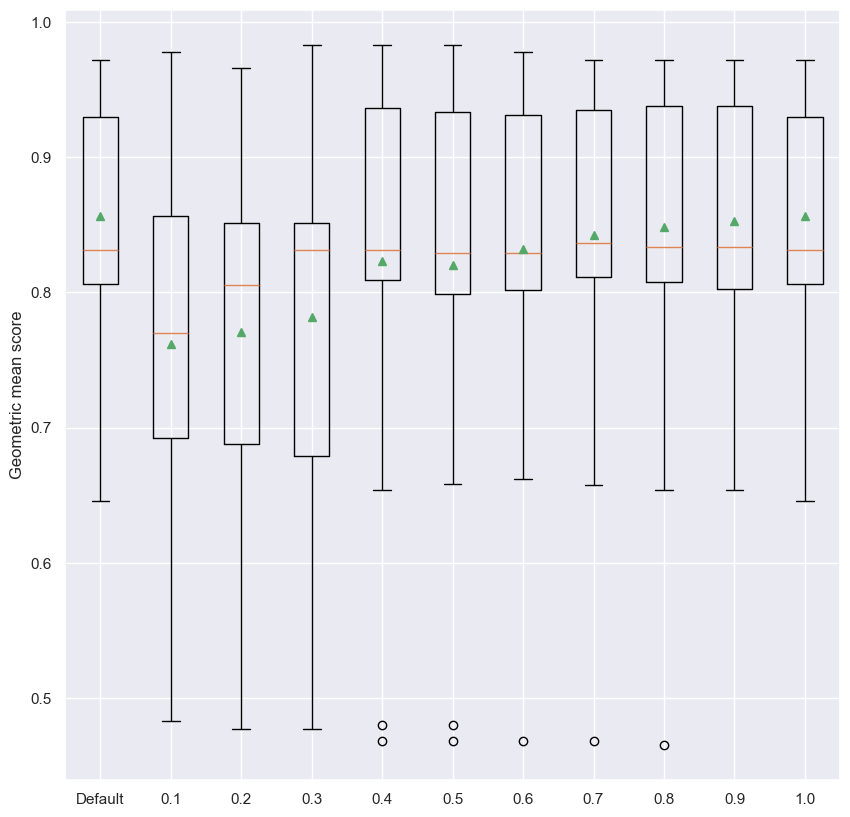

model            mean     std dev    median   IQR     
0.1              0.753942 0.148669   0.770220 0.169137
0.2              0.776218 0.142401   0.831665 0.159377
0.3              0.791662 0.125636   0.824112 0.162363
0.4              0.815015 0.124624   0.833965 0.092524
0.5              0.814468 0.130294   0.824112 0.132310
0.6              0.835418 0.108824   0.824112 0.113842
0.7              0.840006 0.123544   0.829152 0.123483
0.8              0.840069 0.111334   0.831650 0.133820
0.9              0.832906 0.125913   0.826624 0.130810
1.0              0.836675 0.124326   0.831650 0.124441


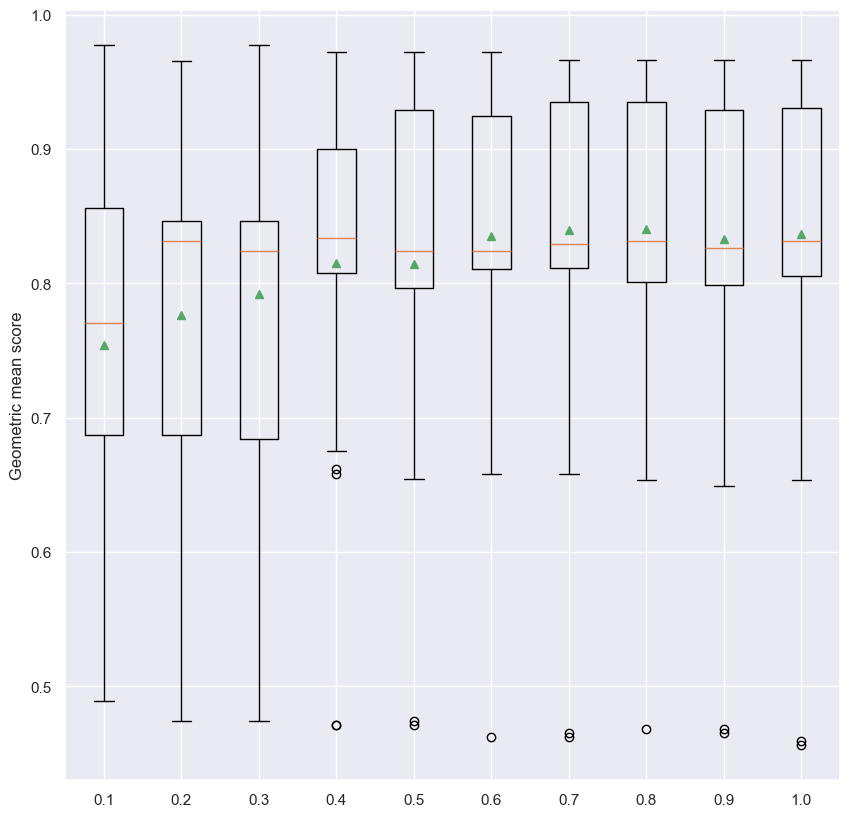

model            mean     std dev    median   IQR     
0.1              0.597115 0.209483   0.695075 0.205953
0.2              0.730872 0.148937   0.705137 0.155292
0.3              0.747272 0.147628   0.734506 0.166032
0.4              0.751792 0.143292   0.730533 0.162198
0.5              0.759764 0.145155   0.796015 0.166490
0.6              0.784132 0.124631   0.796015 0.171067
0.7              0.785043 0.130083   0.828926 0.169353
0.8              0.793909 0.129809   0.823885 0.194277
0.9              0.825119 0.132476   0.828955 0.133940
1.0              0.831357 0.119341   0.826640 0.133940


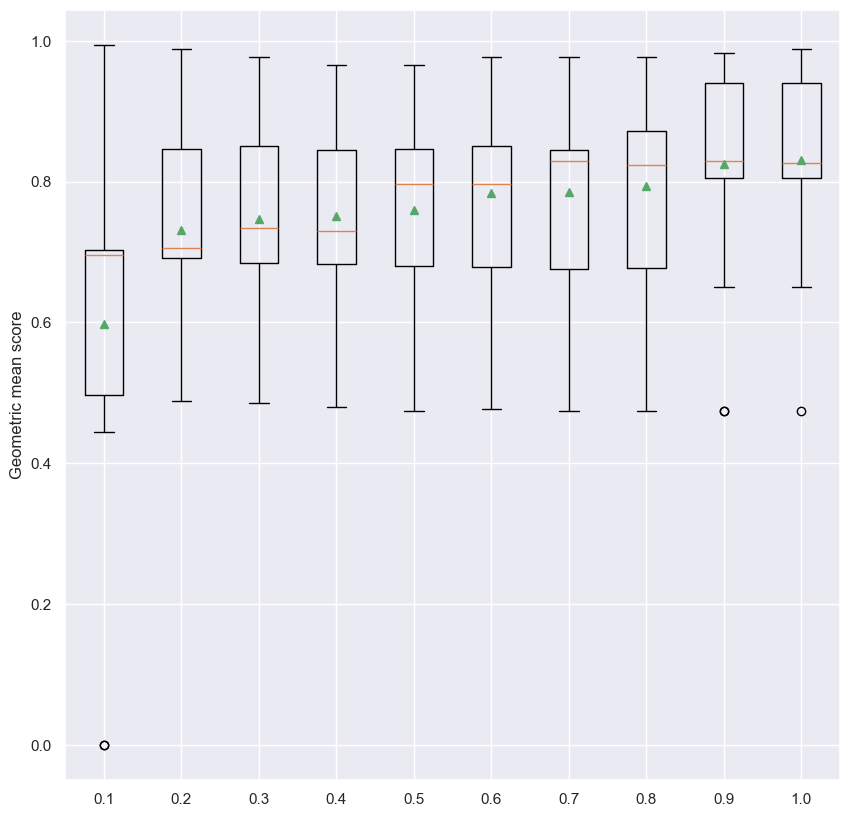

In [148]:
# Construct multiple models by varying the extent to which we oversample the minority class and undersample the majority class.

models = {}
models2 = {}
modelsNM = {}
ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# SMOTEENN + Power transformation (Yeo-Johnson)
models["Default"] = Pipeline(
    steps=[
        ('t1', MinMaxScaler()),
        ('t2', PowerTransformer()),
        ('e', SMOTEENN(random_state=42, 
                       # Use the default undersampling.
                       enn=EditedNearestNeighbours(sampling_strategy='majority'))),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
    ])
for ratio in ratios:
    models[str(ratio)] = Pipeline(
        steps=[
        ('t1', MinMaxScaler()),
        ('t2', PowerTransformer()),
        ('e', SMOTEENN(random_state=42, 
                       sampling_strategy=ratio, 
                       enn=EditedNearestNeighbours(sampling_strategy='majority'))),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
        ])
    
for ratio in ratios:
    models2[str(ratio)] = Pipeline(
        steps=[
        ('t1', MinMaxScaler()),
        ('t2', PowerTransformer()),
        ('e', SMOTEENN(random_state=42, 
                       sampling_strategy=ratio, 
                       enn=EditedNearestNeighbours(sampling_strategy='majority'))),
        ('m', SVC(kernel='linear', probability=True, max_iter=1000, random_state=42))
        ])
    
for ratio in ratios:
    modelsNM[str(ratio)] = Pipeline(
        steps=[
        ('t1', MinMaxScaler()),
        ('t2', PowerTransformer()),
        ('e', SMOTEENN(random_state=42, 
                       sampling_strategy=ratio, 
                       enn=EditedNearestNeighbours(sampling_strategy='not majority'))),
        ('m', LogisticRegression(random_state=42, solver='liblinear'))
        ])

 
evaluate_models(models, X, y)
evaluate_models(models2, X, y)
evaluate_models(modelsNM, X, y) 